# 파생변수 생성·인코딩 및 Stepwise 변수 선택

중복 제거된 데이터를 바탕으로 **Stepwise(전진+후진) 변수 선택**으로 초기 변수를 정하고, 그 변수로 첫 CatBoost 모델을 돌려 성능과 오답 패턴을 확인합니다. 이 결과에서 발라드 곡을 잘 맞히지 못하는 문제가 드러나며, 다음 노트북(`variable_refinement_model_selection`)에서 변수를 보완합니다.

**처리 순서**
- 0. 데이터 불러오기 및 확인
- 1. 변수 선택 (Stepwise Forward + Backward)
- 2. 선정 변수로 모델 실행

# 0. 데이터 불러오기 및 확인
<small>중복 제거가 끝난 데이터(`data(drop_duplicated).csv`)를 다시 불러와 컬럼 구성을 확인합니다.</small>

In [1]:
# 0. 데이터 불러오기: 다른 노트북(01·02·04)과 같은 입력 파일
from pathlib import Path
import pandas as pd

DATA_FILE = Path("../data/data(drop_duplicated).csv")      # 전처리(deduplication)가 만든 분석용 데이터

df_final = pd.read_csv(DATA_FILE)
drop_df = df_final.copy()      # 아래 코드는 drop_df 이름으로 이어짐. 이상치 제외 없이 2,043곡 전체를 사용(성능 수치 유지)

In [2]:
drop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2043 entries, 0 to 2042
Data columns (total 59 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   url                     2043 non-null   object 
 1   songName                2043 non-null   object 
 2   artists                 2043 non-null   object 
 3   video_id                2043 non-null   object 
 4   api_view_count          2043 non-null   float64
 5   api_like_count          2043 non-null   float64
 6   api_comment_count       2043 non-null   float64
 7   api_published_at        2043 non-null   object 
 8   api_duration            2043 non-null   object 
 9   api_channel_title       2043 non-null   object 
 10  valence_raw             2043 non-null   float64
 11  arousal_raw             2043 non-null   float64
 12  valence_normalized      2043 non-null   float64
 13  arousal_normalized      2043 non-null   float64
 14  energy                  2043 non-null   

In [3]:
drop_df.columns

Index(['url', 'songName', 'artists', 'video_id', 'api_view_count',
       'api_like_count', 'api_comment_count', 'api_published_at',
       'api_duration', 'api_channel_title', 'valence_raw', 'arousal_raw',
       'valence_normalized', 'arousal_normalized', 'energy', 'loudness',
       'tempo', 'duration_ms', 'speechiness', 'acoustic_score',
       'sentiment_compound', 'sentiment_positive', 'sentiment_negative',
       'sentiment_neutral', 'avg_brightness', 'avg_motion', 'avg_r_value',
       'avg_g_value', 'avg_b_value', 'frames_analyzed', 'genie_lyrics',
       'genie_genre', 'token_count', 'unique_token_ratio',
       'repeated_token_ratio', 'avg_token_length', 'hapax_legomenon',
       'hapax_dislegomenon', 'hapax_trislegomenon', 'unique_tokens_per_line',
       'avg_tokens_per_line', 'line_count', 'punctuation_ratio',
       'compression_rate', 'pronoun_frequency', 'korean_ratio',
       'english_ratio', 'year', 'month', 'api_duration_sec', 'lyrics_clean',
       'song_title_clea

In [ ]:
# 0-1. 파생변수 생성 + 원핫 인코딩: 1단계(Stepwise)에서 쓸 변수를 먼저 준비합니다.
# (2단계 이후 셀에도 같은 코드가 있으며, 다시 실행해도 결과는 같습니다: 인코딩은 'genie_genre'·'gender'가 남아 있을 때만 수행)
import pandas as pd

# ── 기존 파생변수 ──
drop_df['speechiness_eng']         = drop_df['token_count'] * drop_df['english_ratio'] * drop_df['tempo']
drop_df['rap_globalization_tempo'] = drop_df['speechiness'] * drop_df['english_ratio'] * drop_df['tempo']
drop_df['visual_power']            = drop_df['avg_motion'] * drop_df['energy']
drop_df['sentiment_intensity']     = drop_df['sentiment_compound'].abs() * drop_df['punctuation_ratio']
drop_df['global_emotion']          = drop_df['sentiment_compound'] * drop_df['tempo']
drop_df['ballad_global']           = (1 / (drop_df['tempo'] + 1)) * drop_df['english_ratio'] * drop_df['unique_tokens_per_line']

# ── 추가 파생변수: 시각 ──
drop_df['color_warmth']           = drop_df['avg_r_value'] - drop_df['avg_b_value']
drop_df['color_saturation_proxy'] = (drop_df['avg_r_value'] + drop_df['avg_g_value'] + drop_df['avg_b_value']) / 3
drop_df['visual_audio_energy']    = drop_df['avg_motion'] * drop_df['loudness'].abs()

# ── 추가 파생변수: 음향 ──
drop_df['sound_impact']           = drop_df['energy'] * drop_df['loudness'].abs()
drop_df['acoustic_contrast']      = (1 - drop_df['acoustic_score']) * drop_df['energy']

# ── 추가 파생변수: 가사 ──
drop_df['lyric_repetition']       = drop_df['repeated_token_ratio'] * drop_df['line_count']
drop_df['lyric_intimacy']         = drop_df['pronoun_frequency'] * drop_df['sentiment_compound'].abs()
drop_df['lyric_complexity']       = drop_df['compression_rate'] * drop_df['avg_token_length']
drop_df['pop_sentiment_index']    = drop_df['english_ratio'] * drop_df['valence_normalized'] * drop_df['tempo']


# ════════════════════════════════════════════════════════════
# 2. 원핫 인코딩
# ════════════════════════════════════════════════════════════

if 'genie_genre' in drop_df.columns:
    drop_df = pd.get_dummies(drop_df, columns=['genie_genre'], prefix='genre', drop_first=True)
if 'gender' in drop_df.columns:
    drop_df = pd.get_dummies(drop_df, columns=['gender'], prefix='gender')

# 1. 변수 선택 (Stepwise Forward + Backward)
<small>기본 고정 변수 23개에 후보 변수 20개를 두고, 실제 최종 모델(CatBoost)의 5-Fold CV AUC를 기준으로 추가·제거를 반복하며 변수를 선택합니다.</small>

In [13]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score
from catboost import CatBoostClassifier

# ── 기본 고정 변수 (23개) ──
BASE_FEATURES = [
    'avg_motion', 'avg_brightness', 'visual_power',
    'korean_ratio',
    'rap_globalization_tempo',
    'punctuation_ratio', 'unique_tokens_per_line', 'hapax_legomenon',
    'valence_normalized',
    'is_group', 'api_duration_sec', 'gender_여성', 'gender_혼성',
    'global_emotion', 'speechiness_eng',
    'genre_댄스', 'genre_발라드', 'genre_일렉트로니카',
    'genre_락', 'genre_랩/힙합', 'genre_인디', 'genre_팝',
]

# ── 후보 추가 변수 (20개) ──
CANDIDATE_FEATURES = [
    # 시각
    'avg_r_value', 'avg_g_value', 'avg_b_value',
    'color_warmth', 'color_saturation_proxy', 'visual_audio_energy',
    # 음향
    'energy', 'loudness', 'acoustic_score',
    'sound_impact', 'acoustic_contrast',
    # 가사
    'english_ratio', 'compression_rate', 'pronoun_frequency',
    'repeated_token_ratio', 'unique_token_ratio',
    'lyric_repetition', 'lyric_intimacy', 'lyric_complexity', 'pop_sentiment_index',
]

y = (drop_df['api_view_count'] >= 1_000_000).astype(int)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = CatBoostClassifier(
    iterations=          772,
    learning_rate=       0.019113930760271142,
    depth=               4,
    l2_leaf_reg=         2.2251588705304837,
    bagging_temperature= 0.21762189130109433,
    random_strength=     0.15009890934829523,
    border_count=        142,
    loss_function='Logloss',
    eval_metric='F1',
    random_seed=42,
    verbose=0,
)

def get_score(features):
    X = drop_df[features].copy()
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    return scores.mean()

# ════════════════════════════════════════════════════════════
# Stepwise: Forward + Backward 혼합
# ════════════════════════════════════════════════════════════

selected   = BASE_FEATURES.copy()
remaining  = CANDIDATE_FEATURES.copy()
base_score = get_score(selected)

print("=" * 60)
print(f"기본 23개 변수 AUC: {base_score:.4f}")
print("=" * 60)

step = 0
while True:
    step += 1
    improved = False

    # ── Forward: 후보 중 추가했을 때 가장 성능 오르는 변수 ──
    best_score  = base_score
    best_to_add = None

    for feat in remaining:
        score = get_score(selected + [feat])
        if score > best_score:
            best_score  = score
            best_to_add = feat

    if best_to_add:
        selected.append(best_to_add)
        remaining.remove(best_to_add)
        base_score = best_score
        improved   = True
        print(f"[Step {step}] ✅ 추가: {best_to_add:<30} → AUC {base_score:.4f}")

    # ── Backward: 현재 선택된 후보 변수 중 제거했을 때 성능 오르는 변수 ──
    added_features = [f for f in selected if f not in BASE_FEATURES]
    best_to_remove = None
    best_score_rm  = base_score

    for feat in added_features:
        temp = [f for f in selected if f != feat]
        score = get_score(temp)
        if score > best_score_rm:
            best_score_rm  = score
            best_to_remove = feat

    if best_to_remove:
        selected.remove(best_to_remove)
        remaining.append(best_to_remove)
        base_score = best_score_rm
        improved   = True
        print(f"[Step {step}] ❌ 제거: {best_to_remove:<30} → AUC {base_score:.4f}")

    if not improved:
        print(f"\n[수렴] 더 이상 개선 없음 → 종료")
        break

# ════════════════════════════════════════════════════════════
# 최종 결과
# ════════════════════════════════════════════════════════════

added_final = [f for f in selected if f not in BASE_FEATURES]

print("\n" + "=" * 60)
print(f"최종 선택 변수 수: {len(selected)}개  (기본 23 + 추가 {len(added_final)})")
print(f"최종 AUC        : {base_score:.4f}")
print(f"\n추가된 변수 ({len(added_final)}개):")
for f in added_final:
    print(f"  + {f}")
print("=" * 60)

기본 23개 변수 AUC: 0.8166
[Step 1] ✅ 추가: color_warmth                   → AUC 0.8211
[Step 2] ✅ 추가: avg_r_value                    → AUC 0.8230
[Step 3] ✅ 추가: visual_audio_energy            → AUC 0.8233
[Step 4] ✅ 추가: avg_g_value                    → AUC 0.8239
[Step 5] ✅ 추가: loudness                       → AUC 0.8257

[수렴] 더 이상 개선 없음 → 종료

최종 선택 변수 수: 27개  (기본 23 + 추가 5)
최종 AUC        : 0.8257

추가된 변수 (5개):
  + color_warmth
  + avg_r_value
  + visual_audio_energy
  + avg_g_value
  + loudness


# 2. 선정 변수로 모델 실행
<small>Stepwise로 선택된 변수 조합으로 모델을 실행해 성능을 확인합니다.</small>

데이터 shape    : (2043, 27)
Hit  (≥100만뷰) : 1259개  (61.63%)
Non-Hit         : 784개  (38.37%)
사용 피처 수    : 27

[CatBoost 결과]
Accuracy : 0.7660
Precision: 0.7861
Recall   : 0.8523
F1       : 0.8178
AUC      : 0.8246

Confusion Matrix  →  TN=492, FP=292, FN=186, TP=1073


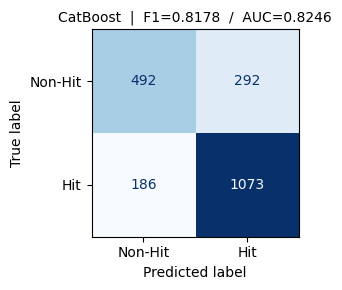

>> Saved: catboost_final_cm.png

[SHAP 분석 중...]


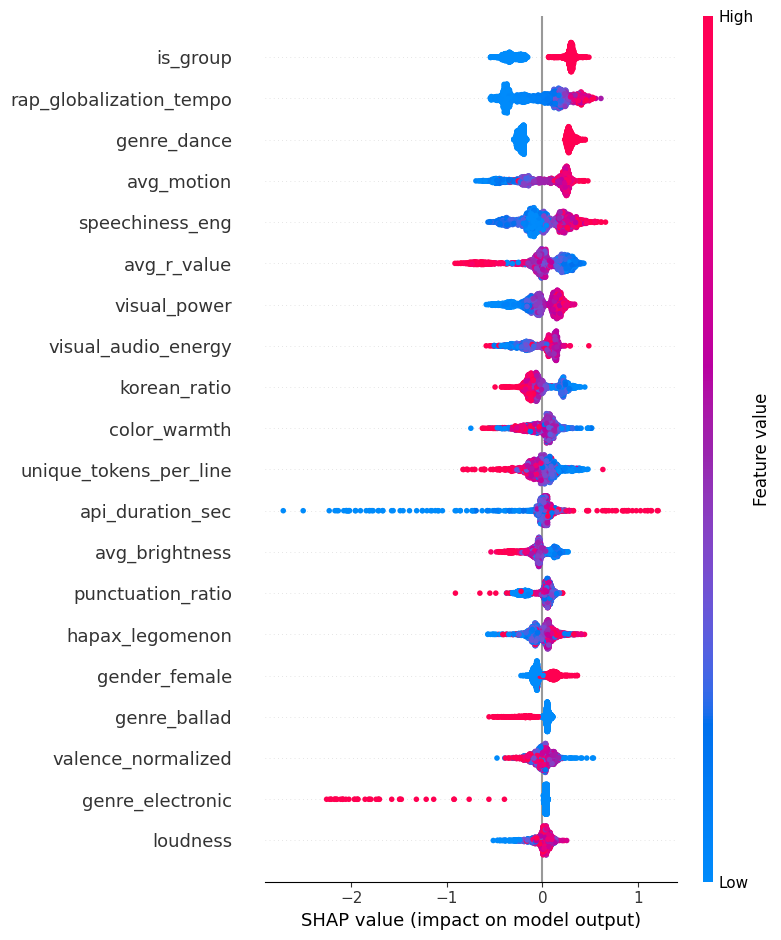

>> Saved: shap_beeswarm.png


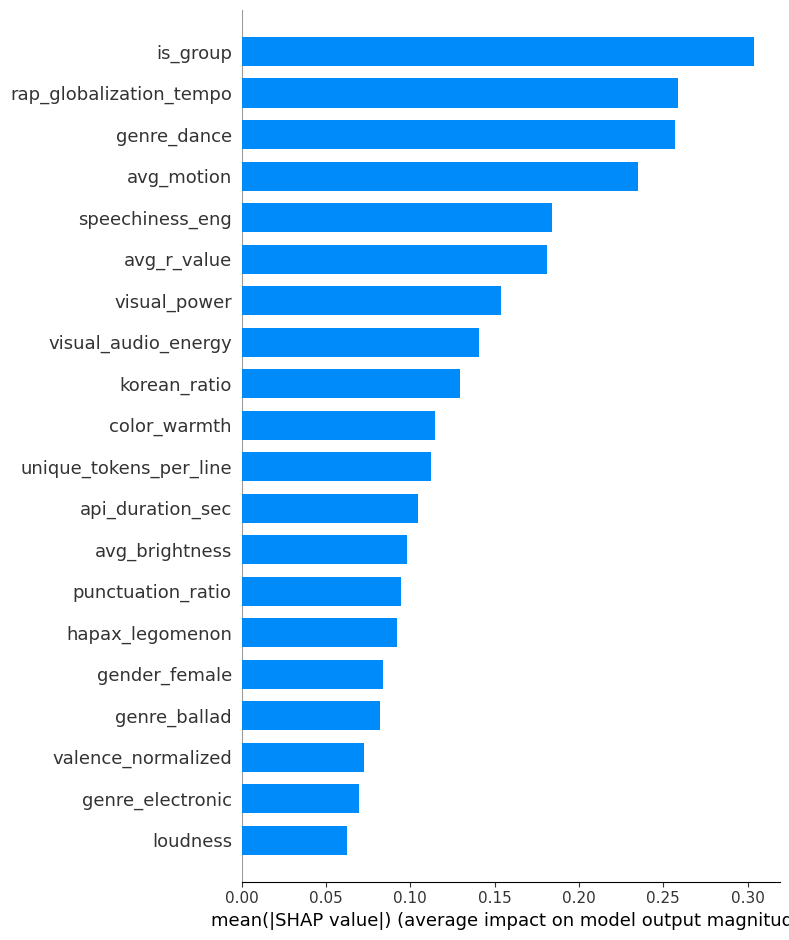

>> Saved: shap_bar.png

[SHAP 특징 중요도 상위 15위]
                feature  mean_shap
               is_group   0.303931
rap_globalization_tempo   0.258943
            genre_dance   0.257166
             avg_motion   0.234915
        speechiness_eng   0.184044
            avg_r_value   0.181202
           visual_power   0.153516
    visual_audio_energy   0.140587
           korean_ratio   0.129583
           color_warmth   0.114480
 unique_tokens_per_line   0.112094
       api_duration_sec   0.104356
         avg_brightness   0.098028
      punctuation_ratio   0.094386
        hapax_legomenon   0.092275

>> Saved: catboost_final_result.csv
>> Saved: shap_importance.csv

[FP 곡: 실제 Non-Hit → 예측 Hit  |  총 292개]
                                             songName                                                                                                         artists  api_view_count                                         url  y_true  y_pred   y_prob
                                     

In [17]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
)
from catboost import CatBoostClassifier
import shap

# ════════════════════════════════════════════════════════════
# 1. 파생변수 생성
# ════════════════════════════════════════════════════════════

# ── 기존 파생변수 ──
drop_df['speechiness_eng']         = drop_df['token_count'] * drop_df['english_ratio'] * drop_df['tempo']
drop_df['rap_globalization_tempo'] = drop_df['speechiness'] * drop_df['english_ratio'] * drop_df['tempo']
drop_df['visual_power']            = drop_df['avg_motion'] * drop_df['energy']
drop_df['sentiment_intensity']     = drop_df['sentiment_compound'].abs() * drop_df['punctuation_ratio']
drop_df['global_emotion']          = drop_df['sentiment_compound'] * drop_df['tempo']
drop_df['ballad_global']           = (1 / (drop_df['tempo'] + 1)) * drop_df['english_ratio'] * drop_df['unique_tokens_per_line']

# ── 추가 파생변수: 시각 ──
drop_df['color_warmth']           = drop_df['avg_r_value'] - drop_df['avg_b_value']
drop_df['color_saturation_proxy'] = (drop_df['avg_r_value'] + drop_df['avg_g_value'] + drop_df['avg_b_value']) / 3
drop_df['visual_audio_energy']    = drop_df['avg_motion'] * drop_df['loudness'].abs()

# ── 추가 파생변수: 음향 ──
drop_df['sound_impact']           = drop_df['energy'] * drop_df['loudness'].abs()
drop_df['acoustic_contrast']      = (1 - drop_df['acoustic_score']) * drop_df['energy']

# ── 추가 파생변수: 가사 ──
drop_df['lyric_repetition']       = drop_df['repeated_token_ratio'] * drop_df['line_count']
drop_df['lyric_intimacy']         = drop_df['pronoun_frequency'] * drop_df['sentiment_compound'].abs()
drop_df['lyric_complexity']       = drop_df['compression_rate'] * drop_df['avg_token_length']
drop_df['pop_sentiment_index']    = drop_df['english_ratio'] * drop_df['valence_normalized'] * drop_df['tempo']


# ════════════════════════════════════════════════════════════
# 2. 원핫 인코딩
# ════════════════════════════════════════════════════════════

if 'genie_genre' in drop_df.columns:
    drop_df = pd.get_dummies(drop_df, columns=['genie_genre'], prefix='genre', drop_first=True)
if 'gender' in drop_df.columns:
    drop_df = pd.get_dummies(drop_df, columns=['gender'], prefix='gender')


# ════════════════════════════════════════════════════════════
# 3. 피처 정의
# ════════════════════════════════════════════════════════════

FEATURES = [
    # ── 기본 23개 ──
    'avg_motion', 'avg_brightness', 'visual_power',
    'korean_ratio',
    'rap_globalization_tempo',
    'punctuation_ratio', 'unique_tokens_per_line', 'hapax_legomenon',
    'valence_normalized',
    'is_group', 'api_duration_sec', 'gender_여성', 'gender_혼성',
    'global_emotion', 'speechiness_eng',
    'genre_댄스', 'genre_발라드', 'genre_일렉트로니카',
    'genre_락', 'genre_랩/힙합', 'genre_인디', 'genre_팝',
    # ── Stepwise 추가 5개 ──
    'color_warmth', 'avg_r_value', 'visual_audio_energy',
    'avg_g_value', 'loudness',
]

FEATURES_EN = [
    # ── 기본 23개 ──
    'avg_motion', 'avg_brightness', 'visual_power',
    'korean_ratio',
    'rap_globalization_tempo',
    'punctuation_ratio', 'unique_tokens_per_line', 'hapax_legomenon',
    'valence_normalized',
    'is_group', 'api_duration_sec', 'gender_female', 'gender_mixed',
    'global_emotion', 'speechiness_eng',
    'genre_dance', 'genre_ballad', 'genre_electronic',
    'genre_rock', 'genre_rap_hiphop', 'genre_indie', 'genre_pop',
    # ── Stepwise 추가 5개 ──
    'color_warmth', 'avg_r_value', 'visual_audio_energy',
    'avg_g_value', 'loudness',
]

# 실제 컬럼 존재 여부 필터링
FEATURES    = [f for f in FEATURES if f in drop_df.columns]
FEATURES_EN = FEATURES_EN[:len(FEATURES)]

X = drop_df[FEATURES].copy()
y = (drop_df['api_view_count'] >= 1_000_000).astype(int)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 60)
print(f"데이터 shape    : {X.shape}")
print(f"Hit  (≥100만뷰) : {int((y==1).sum())}개  ({round(y.mean()*100, 2)}%)")
print(f"Non-Hit         : {int((y==0).sum())}개  ({round((1-y.mean())*100, 2)}%)")
print(f"사용 피처 수    : {len(FEATURES)}")
print("=" * 60)


# ════════════════════════════════════════════════════════════
# 4. CatBoost 학습 & 교차검증
# ════════════════════════════════════════════════════════════

best_model = CatBoostClassifier(
    iterations=          772,
    learning_rate=       0.019113930760271142,
    depth=               4,
    l2_leaf_reg=         2.2251588705304837,
    bagging_temperature= 0.21762189130109433,
    random_strength=     0.15009890934829523,
    border_count=        142,
    loss_function='Logloss',
    eval_metric='F1',
    random_seed=42,
    verbose=0,
)

y_pred = cross_val_predict(best_model, X, y, cv=cv, method='predict')
y_prob = cross_val_predict(best_model, X, y, cv=cv, method='predict_proba')[:, 1]
tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

acc  = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred)
rec  = recall_score(y, y_pred)
f1   = f1_score(y, y_pred)
auc  = roc_auc_score(y, y_prob)

print("\n[CatBoost 결과]")
print("=" * 60)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"AUC      : {auc:.4f}")
print(f"\nConfusion Matrix  →  TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print("=" * 60)


# ════════════════════════════════════════════════════════════
# 5. Confusion Matrix 시각화
# ════════════════════════════════════════════════════════════

cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(4, 3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Hit', 'Hit'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f"CatBoost  |  F1={f1:.4f}  /  AUC={auc:.4f}", fontsize=10)
plt.tight_layout()
plt.savefig('catboost_final_cm.png', dpi=120)
plt.show()
print(">> Saved: catboost_final_cm.png")


# ════════════════════════════════════════════════════════════
# 6. SHAP 분석
# ════════════════════════════════════════════════════════════

print("\n[SHAP 분석 중...]")
best_model.fit(X, y)
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X)

# beeswarm
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X, feature_names=FEATURES_EN, show=False)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=120)
plt.show()
print(">> Saved: shap_beeswarm.png")

# bar
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X, feature_names=FEATURES_EN, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=120)
plt.show()
print(">> Saved: shap_bar.png")

shap_importance = pd.DataFrame({
    'feature': FEATURES_EN,
    'mean_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False).reset_index(drop=True)

print("\n[SHAP 특징 중요도 상위 15위]")
print(shap_importance.head(15).to_string(index=False))


# ════════════════════════════════════════════════════════════
# 7. 결과 저장
# ════════════════════════════════════════════════════════════

pd.DataFrame([{
    '모델': 'CatBoost_final',
    'Accuracy':  round(acc,  4),
    'Precision': round(prec, 4),
    'Recall':    round(rec,  4),
    'F1':        round(f1,   4),
    'AUC':       round(auc,  4),
    'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
}]).to_csv('catboost_final_result.csv', index=False)
print("\n>> Saved: catboost_final_result.csv")

shap_importance.to_csv('shap_importance.csv', index=False)
print(">> Saved: shap_importance.csv")


# ════════════════════════════════════════════════════════════
# 8. FP / FN 오답 분석
# ════════════════════════════════════════════════════════════

result_df = drop_df[['songName', 'artists', 'api_view_count', 'url']].copy()
result_df['y_true'] = y.values
result_df['y_pred'] = y_pred
result_df['y_prob'] = y_prob

fp_df = result_df[(result_df['y_true'] == 0) & (result_df['y_pred'] == 1)].sort_values('y_prob', ascending=False)
fn_df = result_df[(result_df['y_true'] == 1) & (result_df['y_pred'] == 0)].sort_values('y_prob', ascending=True)

print(f"\n[FP 곡: 실제 Non-Hit → 예측 Hit  |  총 {len(fp_df)}개]")
print(fp_df.to_string(index=False))

print(f"\n[FN 곡: 실제 Hit → 예측 Non-Hit  |  총 {len(fn_df)}개]")
print(fn_df.to_string(index=False))

fp_df.to_csv('fp_songs.csv', index=False)
fn_df.to_csv('fn_songs.csv', index=False)
print("\n>> Saved: fp_songs.csv, fn_songs.csv")